In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\car-sales-extended-missing-data.csv')

In [ ]:
df

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


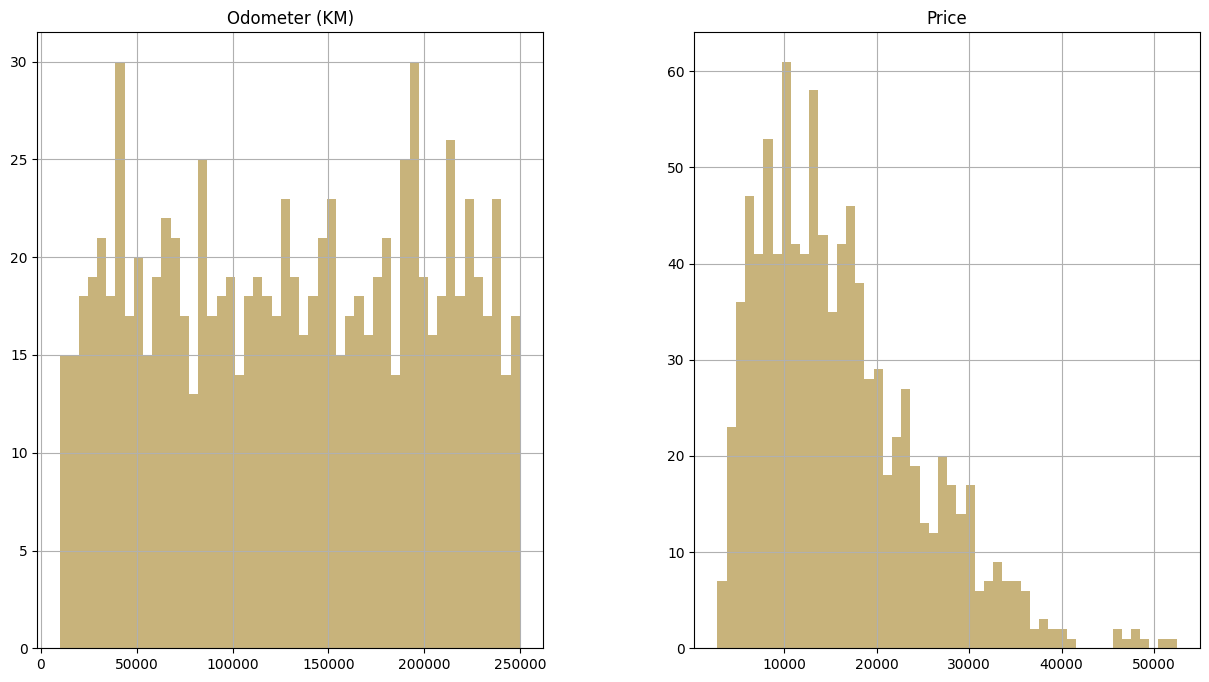

In [20]:
nums_col = ['Odometer (KM)', 'Price']
#df.select_dtypes(include='number').hist(bins=50)

fig = df.loc[:, nums_col].hist(bins=50, figsize=(15, 8), color="#C8B37B")

plt.show()

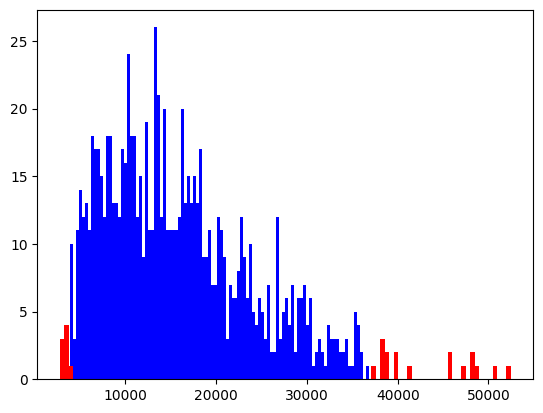

In [41]:
from sklearn.ensemble import IsolationForest
iso_f = IsolationForest(n_estimators=200, contamination=0.025)
pred = iso_f.fit_predict(df[['Price']])
outliers_mask = (pred == -1)

plt.hist(df.loc[~outliers_mask, 'Price'], bins=100, color='b')
plt.hist(df.loc[outliers_mask, 'Price'], bins=100, color='r');

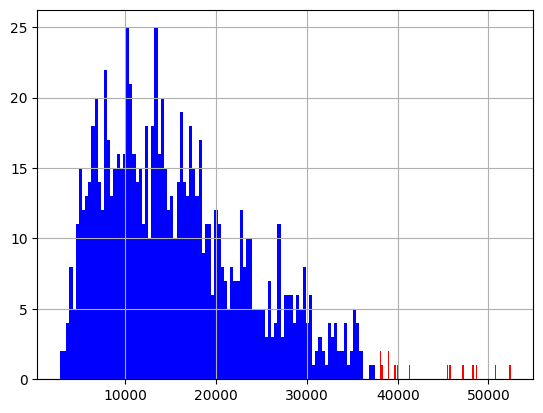

In [42]:
q1, m, q3 = df['Price'].quantile([0.25,0.5, 0.75])

iqr = np.abs(q1 - q3)
lower_limit = q1 - 1.5*iqr 
upper_limit = q3 + 1.5*iqr 

upper_outlier = df['Price'] > upper_limit
lower_outlier = df['Price'] < lower_limit

outlier_mask = upper_outlier | lower_outlier
df.loc[outlier_mask, 'Price'].hist(bins=100, color='red')
df.loc[~outlier_mask, 'Price'].hist(bins=100, color='blue')
plt.show()

In [43]:
df2 = df.loc[~outlier_mask]

In [44]:
df2

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [45]:
num_cols = ['Odometer (KM)', 'Price']
cat_cols = ['Make', 'Colour', 'Doors']

from sklearn.impute import SimpleImputer

ss_num = SimpleImputer(strategy ='median')
output_num = ss_num.fit_transform(df2[num_cols])

ss_cat = SimpleImputer(strategy='most_frequent')
output_cat = ss_cat.fit_transform(df2[cat_cols])

In [47]:
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
output = ord_enc.fit_transform(df2[['Make']])

In [48]:
pd.DataFrame(output, columns=ord_enc.get_feature_names_out())

,Make
0,1.0
1,0.0
2,1.0
3,3.0
4,2.0
...,...
979,3.0
980,NaN
981,2.0
982,1.0


In [51]:
from sklearn.preprocessing import OneHotEncoder

onehot_enc = OneHotEncoder(sparse_output=False)
output_onehot = onehot_enc.fit_transform(df2[['Make']])
output_onehot

array([[0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]], shape=(984, 5))